# Módulo 3 · Análisis Estadístico Exploratorio (EDA)
**Prueba técnica – Analista de Datos**

Fuentes:
- `data/raw/RequerimientosPruebaDatos.csv`: archivo original (7,158 registros de horas).
- `data/clean/RequerimientosPruebaDatos_Limpio.csv`: salida del Módulo 2 (`python/limpieza.py`).

Cada fila es **un registro de horas**: un técnico (`Usuario`) dedica horas a un ticket (`Codigo`) en una actividad (`Accion`) y una fecha.
Por eso un mismo código aparece varias veces sin ser duplicado.

> **Supuesto sobre "Grupo":** el archivo no trae una columna llamada *Grupo*. Se toma `SISTEMA/ CANAL` como el grupo funcional que atiende el ticket (SIC, SAP, HCE, DATOS, etc.).
> Como complemento se usa `Equipo` (Datos vs Aplicaciones), derivado del catálogo de acciones `*_Datos`.

Contenido:
1. Calidad de datos: tabla comparativa Antes vs Después
2. Análisis univariante de Horas (tendencia central, dispersión y forma)
3. Análisis multivariante: promedio de horas por Grupo y por Tipo
4. Conclusiones

In [1]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", None)   # mostrar completos los textos de tratamiento y bitácora
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw" / "RequerimientosPruebaDatos.csv"
LIMPIO = RAIZ / "data" / "clean" / "RequerimientosPruebaDatos_Limpio.csv"
LOG = RAIZ / "data" / "clean" / "log_limpieza.csv"

# Estilo de gráficos: tinta neutra, grilla tenue, un solo color de serie
AZUL = "#2a78d6"
NARANJA = "#eb6834"
TINTA, TINTA_2, GRILLA, EJE = "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"
RAMPA_AZUL = LinearSegmentedColormap.from_list(
    "azul", ["#f4f8fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.family": "sans-serif", "font.size": 10,
    "text.color": TINTA, "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "axes.edgecolor": EJE, "axes.linewidth": 0.8, "axes.grid": True, "grid.color": GRILLA,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 11, "axes.titlelocation": "left",
})

In [2]:
crudo = pd.read_csv(RAW, sep=";", encoding="cp1252", dtype=str, keep_default_na=False)
crudo.columns = ["ID", "REQ", "TIPO", "SISTEMA_CANAL", "USUARIO", "ACCION", "FECHA", "HORAS", "ESTADO"]
limpio = pd.read_csv(LIMPIO, encoding="utf-8-sig", parse_dates=["FechaRegistro"])

print(f"Original: {crudo.shape[0]:,} filas x {crudo.shape[1]} columnas")
print(f"Limpio  : {limpio.shape[0]:,} filas x {limpio.shape[1]} columnas")
limpio.head()

Original: 7,158 filas x 9 columnas
Limpio  : 7,075 filas x 25 columnas


,IdRegistro,Codigo,Tipo,SistemaCanal,Usuario,Equipo,AccionCodigo,Accion,FechaRegistro,Anio,Mes,AnioMes,HorasOriginal,Horas,Estado,EstadoTicket,EsResuelto,FlagFechaImputada,FlagHorasImputadas,FlagHorasAjustadas,FlagEstadoImputado,FlagSistemaImputado,FlagDiaSobrecargado,FilaOrigen,FechaOriginal
0,1,REQ 2024-022552,PRY,MAC,CRODRIGUEZ,Aplicaciones,4,04_Desarrollo,2026-01-02,2026,1,2026-01,9.50,9.50,Cerrado,Cerrado,1,0,0,0,0,0,0,2,02/01/2026
1,2,INC 2026-000053,INC,APP/ WEB,JROSALES,Aplicaciones,2,02_Análisis,2026-01-02,2026,1,2026-01,0.75,0.75,Cerrado,Cerrado,1,0,0,0,0,0,0,3,02/01/2026
2,3,INC 2026-000080,INC,APP/ WEB,JROSALES,Aplicaciones,2,02_Análisis,2026-01-02,2026,1,2026-01,0.75,0.75,Cerrado,Cerrado,1,0,0,0,0,0,0,4,02/01/2026
3,4,INC 2026-000092,INC,APP/ WEB,JROSALES,Aplicaciones,2,02_Análisis,2026-01-02,2026,1,2026-01,0.75,0.75,Cerrado,Cerrado,1,0,0,0,0,0,0,5,02/01/2026
4,5,INC 2026-000113,INC,APP/ WEB,JROSALES,Aplicaciones,2,02_Análisis,2026-01-02,2026,1,2026-01,0.75,0.75,Cerrado,Cerrado,1,0,0,0,0,0,0,6,02/01/2026


## 1. Calidad de datos: Antes vs Después
Se considera *nulo o vacío* un campo en blanco, con solo espacios o con el texto literal `NULL`.
Para la fecha se suman además las fechas que no existen en el calendario (p. ej. `32/11/2026`).

In [3]:
def vacio(s: pd.Series) -> pd.Series:
    t = s.str.replace("\xa0", " ", regex=False).str.strip()
    return t.eq("") | t.str.upper().eq("NULL")

fecha_ok = pd.to_datetime(crudo["FECHA"], format="%d/%m/%Y", errors="coerce")
fecha_invalida = ~vacio(crudo["FECHA"]) & fecha_ok.isna()

nulos_antes = {
    "ID": vacio(crudo["ID"]).sum(),
    "SistemaCanal": vacio(crudo["SISTEMA_CANAL"]).sum(),
    "Usuario": vacio(crudo["USUARIO"]).sum(),
    "Accion": vacio(crudo["ACCION"]).sum(),
    "Fecha (vacía + inválida)": vacio(crudo["FECHA"]).sum() + fecha_invalida.sum(),
    "Horas": vacio(crudo["HORAS"]).sum(),
    "Estado": vacio(crudo["ESTADO"]).sum(),
}
tratamiento = {
    "ID": "Columna eliminada (100% vacía); se crea IdRegistro",
    "SistemaCanal": f"{limpio['FlagSistemaImputado'].sum() - (limpio['SistemaCanal'] == 'NO ESPECIFICADO').sum()} recuperados del mismo ticket; "
                    f"{(limpio['SistemaCanal'] == 'NO ESPECIFICADO').sum()} = 'NO ESPECIFICADO'",
    "Usuario": f"{(limpio['Usuario'] == 'NO IDENTIFICADO').sum()} = 'NO IDENTIFICADO'",
    "Accion": f"{(limpio['Accion'] == '00_No Especificado').sum()} = '00_No Especificado'",
    "Fecha (vacía + inválida)": f"{limpio['FlagFechaImputada'].sum()} imputadas por posición cronológica",
    "Horas": f"{limpio['FlagHorasImputadas'].sum()} imputadas con la mediana de su acción",
    "Estado": f"{limpio['FlagEstadoImputado'].sum() - (limpio['Estado'] == 'Sin Estado').sum()} recuperados del ticket; "
              f"{(limpio['Estado'] == 'Sin Estado').sum()} = 'Sin Estado'",
}
# Nulos que quedan en el archivo limpio (se calcula, no se asume)
columna_limpia = {"SistemaCanal": "SistemaCanal", "Usuario": "Usuario", "Accion": "Accion",
                  "Fecha (vacía + inválida)": "FechaRegistro", "Horas": "Horas", "Estado": "Estado"}
nulos_despues = {k: (int(limpio[c].isna().sum()) if c else 0) for k, c in {"ID": None, **columna_limpia}.items()}
# Si el conteo de origen supera las correcciones es porque esas filas eran duplicadas y se retiraron
corregidos = {"Fecha (vacía + inválida)": limpio["FlagFechaImputada"].sum(), "Estado": limpio["FlagEstadoImputado"].sum()}
for col, n in corregidos.items():
    if nulos_antes[col] > n:
        tratamiento[col] += f" (+{nulos_antes[col] - n} en fila duplicada retirada)"
calidad_nulos = pd.DataFrame({
    "Nulos/vacíos ANTES": pd.Series(nulos_antes),
    "% ANTES": pd.Series(nulos_antes) / len(crudo) * 100,
    "Nulos DESPUÉS": pd.Series(nulos_despues),
    "Tratamiento": pd.Series(tratamiento),
})
calidad_nulos

,Nulos/vacíos ANTES,% ANTES,Nulos DESPUÉS,Tratamiento
ID,7158,100.00,0,Columna eliminada (100% vacía); se crea IdRegistro
SistemaCanal,36,0.50,0,15 recuperados del mismo ticket; 21 = 'NO ESPECIFICADO'
Usuario,39,0.54,0,39 = 'NO IDENTIFICADO'
Accion,24,0.34,0,24 = '00_No Especificado'
Fecha (vacía + inválida),55,0.77,0,54 imputadas por posición cronológica (+1 en fila duplicada retirada)
Horas,45,0.63,0,45 imputadas con la mediana de su acción
Estado,105,1.47,0,55 recuperados del ticket; 49 = 'Sin Estado' (+1 en fila duplicada retirada)


In [4]:
horas_antes = pd.to_timedelta(crudo["HORAS"].replace("", np.nan)).dt.total_seconds() / 3600
duplicados_exactos = crudo.duplicated().sum()

resumen = pd.DataFrame([
    ("Filas procesadas", len(crudo), len(limpio)),
    ("Duplicados exactos en origen", duplicados_exactos, 0),
    ("Duplicados tras estandarizar (adicionales)", len(crudo) - len(limpio) - duplicados_exactos, 0),
    ("Celdas nulas, vacías o con fecha inválida (sin contar ID)", sum(nulos_antes.values()) - nulos_antes["ID"],
     int(limpio.drop(columns=["HorasOriginal", "FechaOriginal"]).isna().sum().sum())),
    ("Códigos (tickets) únicos", crudo["REQ"].nunique(), limpio["Codigo"].nunique()),
    ("Valores distintos de Estado (sin vacío)", crudo.loc[~vacio(crudo["ESTADO"]), "ESTADO"].nunique(),
     limpio.loc[limpio["Estado"] != "Sin Estado", "Estado"].nunique()),
    ("Valores distintos de Sistema/Canal (sin vacío)", crudo.loc[~vacio(crudo["SISTEMA_CANAL"]), "SISTEMA_CANAL"].nunique(),
     limpio.loc[limpio["SistemaCanal"] != "NO ESPECIFICADO", "SistemaCanal"].nunique()),
    ("Valores distintos de Acción (sin vacío)", crudo.loc[~vacio(crudo["ACCION"]), "ACCION"].nunique(),
     limpio.loc[limpio["Accion"] != "00_No Especificado", "Accion"].nunique()),
    ("Fechas fuera de calendario", fecha_invalida.sum(), 0),
    ("Registros > 10 h (extremos)", (horas_antes > 10).sum(), (limpio["Horas"] > 10).sum()),
    ("Horas totales", round(horas_antes.sum(), 2), round(limpio["Horas"].sum(), 2)),
], columns=["Indicador", "Antes", "Después"]).set_index("Indicador")
resumen["Variación"] = resumen["Después"] - resumen["Antes"]
# Conteos sin decimales; solo las horas llevan 2 decimales
resumen.style.format(lambda v: f"{v:,.0f}" if float(v).is_integer() else f"{v:,.2f}")

,Antes,Después,Variación
Indicador,,,
Filas procesadas,"7,158","7,075",-83
Duplicados exactos en origen,71,0,-71
Duplicados tras estandarizar (adicionales),12,0,-12
"Celdas nulas, vacías o con fecha inválida (sin contar ID)",304,0,-304
Códigos (tickets) únicos,"3,407","3,406",-1
Valores distintos de Estado (sin vacío),5,3,-2
Valores distintos de Sistema/Canal (sin vacío),20,19,-1
Valores distintos de Acción (sin vacío),28,27,-1
Fechas fuera de calendario,22,0,-22


**Lectura:** la fuente tiene buena completitud (ninguna columna útil supera el 1.5% de vacíos), pero presenta problemas de **consistencia**:
estados con distinto género (`Cerrada`/`Cerrado`), un sinónimo de acción (`02_Analizado`), un espacio duro en `PORTAL PROVEEDORES`, fechas inexistentes y 83 registros duplicados.
Las 230 horas de diferencia se explican por los duplicados retirados y por acotar 55 registros extremos (las horas imputadas suman en sentido contrario).

Bitácora completa generada por el script de limpieza:

In [5]:
pd.read_csv(LOG, encoding="utf-8-sig")

,Regla,Columna,Problema,Tratamiento,FilasAfectadas
0,0-Estructura,ID,Columna 100% vacía,Se elimina; se genera IdRegistro secuencial,7158
1,0-Texto,SistemaCanal,Espacio duro (NBSP) dentro del texto,Se reemplaza por espacio normal,29
2,0-Texto,Estado,Texto literal 'NULL',Se convierte a nulo real,105
3,2-Categorías,Codigo,Prefijo en minúsculas ('Req'),Se pasa a mayúsculas,1
4,2-Categorías,SistemaCanal,Error tipográfico 'AGENDA PROCEDMIENTOS',Se corrige la etiqueta,15
5,2-Categorías,Accion,Sinónimo '02_Analizado' de '02_Analisis',Se unifica en una sola acción,12
6,2-Categorías,Accion,Ortografía inconsistente (Reunion/Analisis/Estimacion sin tilde),Se uniforma con tildes,4217
7,2-Categorías,Estado,"Mismo estado escrito distinto (Cerrada/Cerrado, Resuelta/Resuelto)","Se uniforma: Cerrado, Resuelto, Asignado",6216
8,1-Duplicados,(todas),Registro idéntico byte a byte en el CSV original,Se conserva la primera aparición,71
9,1-Duplicados,(todas),Registro idéntico solo después de estandarizar (p.ej. Cerrada/Cerrado),Se conserva la primera aparición,12


## 2. Análisis univariante: Horas
Se analiza `Horas` del archivo limpio (registro individual, en horas decimales). Como referencia se muestra la misma variable antes del tratamiento
(`HorasOriginal`: sin duplicados, pero con nulos y valores extremos).

In [6]:
def describir(x: pd.Series) -> pd.Series:
    x = x.dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    return pd.Series({
        "n": len(x),
        "Media": x.mean(),
        "Mediana": x.median(),
        "Moda": x.mode().iat[0],
        "Desviación estándar": x.std(),
        "Varianza": x.var(),
        "Q1": q1,
        "Q3": q3,
        "Rango intercuartílico (IQR)": q3 - q1,
        "Mínimo": x.min(),
        "Máximo": x.max(),
        "Coef. de variación": x.std() / x.mean(),
        "Asimetría (skewness)": stats.skew(x, bias=False),
        "Curtosis (exceso, Fisher)": stats.kurtosis(x, fisher=True, bias=False),
    })

univariante = pd.DataFrame({
    "Horas tratadas (limpio)": describir(limpio["Horas"]),
    "Horas originales (sin tratar)": describir(limpio["HorasOriginal"]),
})
univariante

,Horas tratadas (limpio),Horas originales (sin tratar)
n,"7,075.00","7,030.00"
Media,2.40,2.42
Mediana,1.50,1.50
Moda,1.00,1.00
Desviación estándar,2.58,2.63
Varianza,6.66,6.91
Q1,0.67,0.67
Q3,3.00,3.00
Rango intercuartílico (IQR),2.33,2.33
Mínimo,0.17,0.17


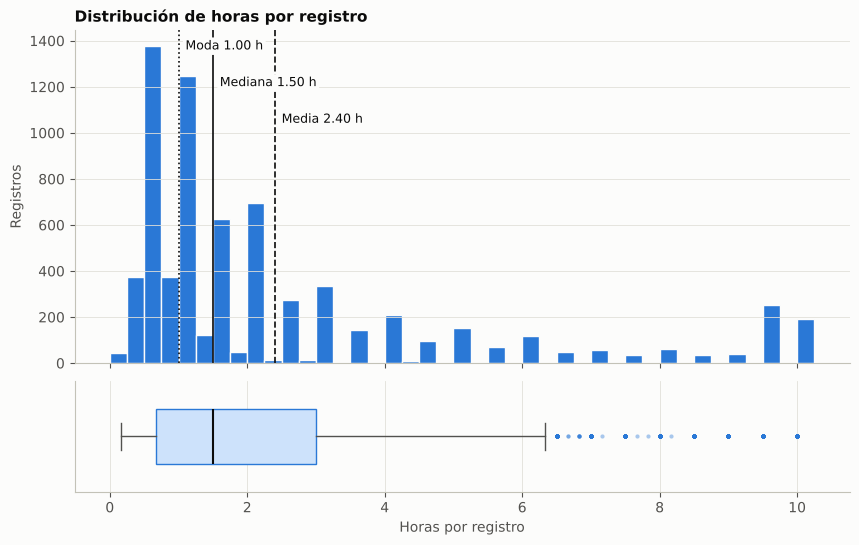

In [7]:
h = limpio["Horas"]
media, mediana, moda = h.mean(), h.median(), h.mode().iat[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})
ax1.hist(h, bins=np.arange(0, 10.5, 0.25), color=AZUL, edgecolor="#fcfcfb", linewidth=1)
tope_y = ax1.get_ylim()[1]
for valor, etiqueta, estilo, altura in [(moda, "Moda", ":", 0.97), (mediana, "Mediana", "-", 0.86), (media, "Media", "--", 0.75)]:
    ax1.axvline(valor, color=TINTA, linestyle=estilo, linewidth=1.2)
    ax1.annotate(f"{etiqueta} {valor:.2f} h", xy=(valor, tope_y * altura), xytext=(5, 0),
                 textcoords="offset points", fontsize=9, color=TINTA, va="top",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="#fcfcfb", edgecolor="none"))
ax1.set_title("Distribución de horas por registro")
ax1.set_ylabel("Registros")
ax1.grid(axis="x", visible=False)

# matplotlib >= 3.10 usa orientation=; versiones anteriores, vert=False
horizontal = {"orientation": "horizontal"} if tuple(map(int, matplotlib.__version__.split(".")[:2])) >= (3, 10) else {"vert": False}
ax2.boxplot(h, **horizontal, widths=0.5, patch_artist=True,
            boxprops=dict(facecolor="#cde2fb", edgecolor=AZUL), medianprops=dict(color=TINTA, linewidth=1.5),
            whiskerprops=dict(color=TINTA_2), capprops=dict(color=TINTA_2),
            flierprops=dict(marker="o", markersize=3, markerfacecolor=AZUL, markeredgecolor="none", alpha=0.4))
ax2.set_yticks([])
ax2.set_xlabel("Horas por registro")
ax2.grid(axis="y", visible=False)
plt.show()

In [8]:
asim = stats.skew(h, bias=False)
curt = stats.kurtosis(h, bias=False)
print(f"Media ({media:.2f} h) > Mediana ({mediana:.2f} h) > Moda ({moda:.2f} h)  -> sesgo a la derecha")
print(f"Asimetría = {asim:.2f}  (> 1: fuertemente asimétrica positiva)")
print(f"Curtosis  = {curt:.2f}  (> 0: colas más pesadas que una normal / leptocúrtica)")
print(f"CV = {h.std() / media:.0%}  -> dispersión alta: la media no representa bien al registro típico")
print(f"Registros > 6.5 h (atípicos moderados, Q3 + 1.5*IQR): {(h > 6.5).sum():,} ({(h > 6.5).mean():.1%})")

Media (2.40 h) > Mediana (1.50 h) > Moda (1.00 h)  -> sesgo a la derecha
Asimetría = 1.75  (> 1: fuertemente asimétrica positiva)
Curtosis  = 2.10  (> 0: colas más pesadas que una normal / leptocúrtica)
CV = 108%  -> dispersión alta: la media no representa bien al registro típico
Registros > 6.5 h (atípicos moderados, Q3 + 1.5*IQR): 682 (9.6%)


**Interpretación**
- **Tendencia central:** el registro típico es corto. La moda es 1 h y la mediana 1.5 h, mientras que la media sube a ~2.4 h, arrastrada por los registros de jornada completa (9.5–10 h), sobre todo de REQ largos (56%) y PRY (39%).
- **Dispersión:** la desviación estándar (~2.6 h) es mayor que la propia media (CV > 100%) y el IQR es de 2.33 h (entre 40 min y 3 h). Para reportar el "esfuerzo típico" conviene usar la **mediana**, no la media.
- **Forma:** distribución **asimétrica positiva** (skewness ≈ 1.75) y **leptocúrtica** (curtosis ≈ 2.1): muchos registros pequeños y una cola larga de registros de día completo.
  El tratamiento redujo ambas medidas (antes 1.82 y 2.52) sin borrar información: los valores originales siguen en `HorasOriginal`.
- Los ~680 registros entre 6.5 h y 10 h son atípicos estadísticos pero **no errores**: en su mayoría (65%) son el único registro del técnico ese día, y entre los de 9.5 h o más la proporción sube al 93%. Es coherente con la jornada de 9.5 h que se observa por técnico.

## 3. Análisis multivariante: horas por Grupo y por Tipo
Se mide el esfuerzo de dos formas complementarias:
- **Promedio de horas por registro** (cuánto dura cada sesión de trabajo).
- **Promedio de horas por ticket** (horas totales que consume un requerimiento hasta hoy) – es la medida de negocio.

In [9]:
por_tipo = (limpio.groupby("Tipo")
            .agg(Registros=("Horas", "size"), Tickets=("Codigo", "nunique"), HorasTotales=("Horas", "sum"),
                 PromHorasRegistro=("Horas", "mean"), MedianaHorasRegistro=("Horas", "median")))
por_tipo["PromHorasTicket"] = por_tipo["HorasTotales"] / por_tipo["Tickets"]
por_tipo["% Tickets"] = por_tipo["Tickets"] / limpio["Codigo"].nunique() * 100
por_tipo["% Horas"] = por_tipo["HorasTotales"] / limpio["Horas"].sum() * 100
por_tipo.sort_values("HorasTotales", ascending=False)

,Registros,Tickets,HorasTotales,PromHorasRegistro,MedianaHorasRegistro,PromHorasTicket,% Tickets,% Horas
Tipo,,,,,,,,
REQ,3613,1223,"9,830.17",2.72,1.50,8.04,35.91,57.90
PRY,825,17,"3,775.17",4.58,3.50,222.07,0.50,22.23
INC,1657,1414,"1,835.00",1.11,0.83,1.30,41.51,10.81
EXP,980,752,"1,538.42",1.57,1.00,2.05,22.08,9.06


In [10]:
# Promedio de horas por Grupo (Sistema/Canal): por registro y por ticket
por_grupo = (limpio.groupby("SistemaCanal")
             .agg(Registros=("Horas", "size"), Tickets=("Codigo", "nunique"), HorasTotales=("Horas", "sum"),
                  PromHorasRegistro=("Horas", "mean"), MedianaHorasRegistro=("Horas", "median")))
por_grupo["PromHorasTicket"] = por_grupo["HorasTotales"] / por_grupo["Tickets"]
por_grupo["% Registros"] = por_grupo["Registros"] / len(limpio) * 100
por_grupo["% Horas"] = por_grupo["HorasTotales"] / limpio["Horas"].sum() * 100
por_grupo.sort_values("HorasTotales", ascending=False)

,Registros,Tickets,HorasTotales,PromHorasRegistro,MedianaHorasRegistro,PromHorasTicket,% Registros,% Horas
SistemaCanal,,,,,,,,
SIC,3400,1845,"6,445.91",1.90,1.00,3.49,48.06,37.96
MAC,521,213,"1,827.58",3.51,1.50,8.58,7.36,10.76
DATOS,539,57,"1,738.50",3.23,2.00,30.50,7.62,10.24
APP/ WEB,723,440,"1,510.33",2.09,1.50,3.43,10.22,8.90
HCE,381,164,"1,190.25",3.12,2.00,7.26,5.39,7.01
HCE UNIFICADA,156,3,"1,120.00",7.18,9.50,373.33,2.20,6.60
HIS,262,65,963.67,3.68,2.17,14.83,3.70,5.68
AGENDA CITAS,277,141,649.75,2.35,1.50,4.61,3.92,3.83
SAP,446,335,482.17,1.08,1.00,1.44,6.30,2.84


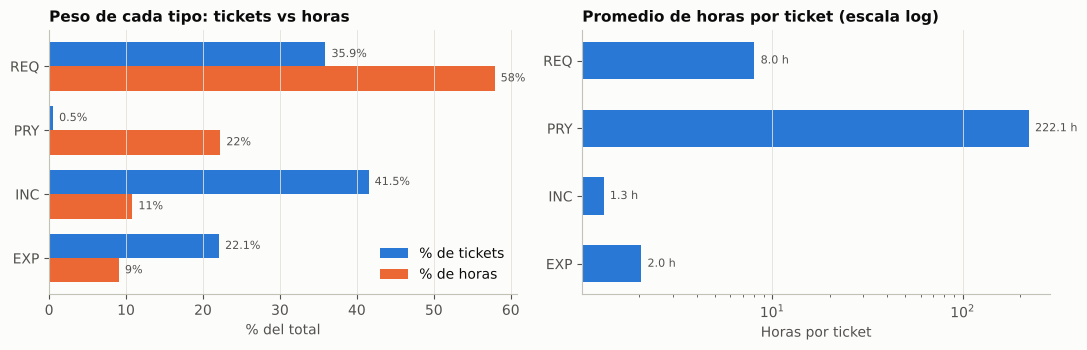

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
orden = por_tipo.sort_values("% Horas").index
y = np.arange(len(orden))
alto = 0.38
axes[0].barh(y + alto / 2, por_tipo.loc[orden, "% Tickets"], height=alto, color=AZUL, label="% de tickets")
axes[0].barh(y - alto / 2, por_tipo.loc[orden, "% Horas"], height=alto, color=NARANJA, label="% de horas")
axes[0].set_yticks(y, orden)
axes[0].set_title("Peso de cada tipo: tickets vs horas")
axes[0].set_xlabel("% del total")
axes[0].legend(frameon=False, loc="lower right")
axes[0].grid(axis="y", visible=False)
for i, t in enumerate(orden):
    axes[0].text(por_tipo.loc[t, "% Horas"] + 0.8, i - alto / 2, f"{por_tipo.loc[t, '% Horas']:.0f}%", va="center", fontsize=8, color=TINTA_2)
    axes[0].text(por_tipo.loc[t, "% Tickets"] + 0.8, i + alto / 2, f"{por_tipo.loc[t, '% Tickets']:.1f}%", va="center", fontsize=8, color=TINTA_2)

axes[1].barh(y, por_tipo.loc[orden, "PromHorasTicket"], height=0.55, color=AZUL)
axes[1].set_xscale("log")
axes[1].set_yticks(y, orden)
axes[1].set_title("Promedio de horas por ticket (escala log)")
axes[1].set_xlabel("Horas por ticket")
axes[1].grid(axis="y", visible=False)
for i, t in enumerate(orden):
    axes[1].text(por_tipo.loc[t, "PromHorasTicket"] * 1.08, i, f"{por_tipo.loc[t, 'PromHorasTicket']:,.1f} h", va="center", fontsize=8, color=TINTA_2)
plt.tight_layout()
plt.show()

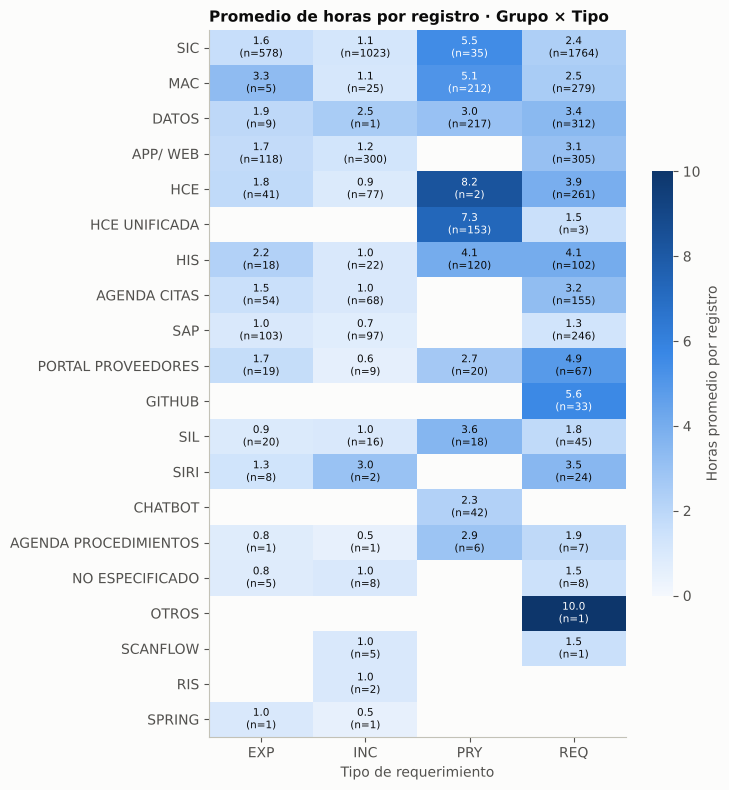

In [12]:
# Matriz Grupo (Sistema/Canal) x Tipo: promedio de horas por REGISTRO
grupos = limpio.groupby("SistemaCanal")["Horas"].sum().sort_values(ascending=False).index
matriz_registro = limpio.pivot_table(index="SistemaCanal", columns="Tipo", values="Horas", aggfunc="mean").reindex(grupos)
conteo = limpio.pivot_table(index="SistemaCanal", columns="Tipo", values="Horas", aggfunc="size").reindex(grupos)

fig, ax = plt.subplots(figsize=(7.5, 8))
im = ax.imshow(matriz_registro.values, cmap=RAMPA_AZUL, aspect="auto", vmin=0, vmax=10)
ax.set_xticks(range(matriz_registro.shape[1]), matriz_registro.columns)
ax.set_yticks(range(matriz_registro.shape[0]), matriz_registro.index)
ax.grid(False)
for i in range(matriz_registro.shape[0]):
    for j in range(matriz_registro.shape[1]):
        v = matriz_registro.iat[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.1f}\n(n={int(conteo.iat[i, j])})", ha="center", va="center", fontsize=7.5,
                    color="#ffffff" if v > 5 else TINTA)
ax.set_title("Promedio de horas por registro · Grupo × Tipo")
ax.set_xlabel("Tipo de requerimiento")
cb = fig.colorbar(im, ax=ax, shrink=0.6)
cb.set_label("Horas promedio por registro")
cb.outline.set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
# Promedio de horas por TICKET (se suma por ticket y luego se promedia)
por_ticket = limpio.groupby(["SistemaCanal", "Tipo", "Codigo"], as_index=False)["Horas"].sum()
matriz_ticket = por_ticket.pivot_table(index="SistemaCanal", columns="Tipo", values="Horas", aggfunc="mean").reindex(grupos)
matriz_ticket["Total grupo"] = por_ticket.groupby("SistemaCanal")["Horas"].mean().reindex(grupos)
matriz_ticket.loc["Total tipo"] = list(por_ticket.groupby("Tipo")["Horas"].mean().reindex(matriz_ticket.columns[:-1])) + [por_ticket["Horas"].mean()]
matriz_ticket.round(1).style.format("{:,.1f}", na_rep="–").background_gradient(cmap=RAMPA_AZUL, axis=None, vmin=0, vmax=60)

Tipo,EXP,INC,PRY,REQ,Total grupo
SistemaCanal,,,,,
SIC,2.3,1.4,38.4,6.9,3.5
MAC,8.2,1.3,"1,080.4",3.7,8.6
DATOS,2.1,2.5,653.9,22.7,30.5
APP/ WEB,2.2,1.3,–,15.6,3.4
HCE,2.4,1.1,16.5,16.0,7.3
HCE UNIFICADA,–,–,"1,115.5",2.2,373.3
HIS,3.1,1.1,162.3,14.8,14.8
AGENDA CITAS,1.7,1.1,–,17.3,4.6
SAP,1.1,0.8,–,2.0,1.4


In [14]:
# ¿Las diferencias entre tipos y grupos son estadísticamente significativas?
# Horas no es normal (asimétrica) -> prueba no paramétrica de Kruskal-Wallis.
kw_tipo = stats.kruskal(*[g["Horas"].values for _, g in limpio.groupby("Tipo")])
top_grupos = limpio["SistemaCanal"].value_counts().loc[lambda s: s >= 30].index
kw_grupo = stats.kruskal(*[g["Horas"].values for k, g in limpio.groupby("SistemaCanal") if k in top_grupos])
print(f"Horas por registro según Tipo : H = {kw_tipo.statistic:,.1f}  p-valor = {kw_tipo.pvalue:.1e}")
print(f"Horas por registro según Grupo: H = {kw_grupo.statistic:,.1f}  p-valor = {kw_grupo.pvalue:.1e}  ({len(top_grupos)} grupos con n >= 30)")
n_tipo = len(limpio)
n_grupo = int(limpio["SistemaCanal"].isin(top_grupos).sum())
print(f"Tamaño del efecto (épsilon² = H / (n - 1)): Tipo {kw_tipo.statistic / (n_tipo - 1):.3f} · "
      f"Grupo {kw_grupo.statistic / (n_grupo - 1):.3f}")
print("-> En ambos casos p < 0.05: el esfuerzo depende del tipo y del grupo; no es aleatorio.")
print("   Nota: los registros no son del todo independientes (varios por ticket y por técnico); con n tan grande")
print("   cualquier diferencia sale significativa, por eso se informa también el tamaño del efecto.")

Horas por registro según Tipo : H = 1,183.5  p-valor = 2.8e-256
Horas por registro según Grupo: H = 791.1  p-valor = 1.1e-160  (14 grupos con n >= 30)
Tamaño del efecto (épsilon² = H / (n - 1)): Tipo 0.167 · Grupo 0.113
-> En ambos casos p < 0.05: el esfuerzo depende del tipo y del grupo; no es aleatorio.
   Nota: los registros no son del todo independientes (varios por ticket y por técnico); con n tan grande
   cualquier diferencia sale significativa, por eso se informa también el tamaño del efecto.


In [15]:
# Complemento: equipo y perfil de los técnicos (insumo para el Módulo 5)
# Equipo clasifica la ACTIVIDAD (catálogo *_Datos), no a la persona: los 5 técnicos con registros
# de Datos (sobre todo AINGA y ACARRASCO) también tienen registros de Aplicaciones, por eso los
# dos equipos suman 24 técnicos y no 19.
con_usuario = limpio[limpio["Usuario"] != "NO IDENTIFICADO"]
por_equipo = con_usuario.groupby("Equipo").agg(TecnicosConRegistros=("Usuario", "nunique"), Tickets=("Codigo", "nunique"),
                                               Horas=("Horas", "sum"), PromHorasRegistro=("Horas", "mean"))
por_equipo["HorasPorTicket"] = por_equipo["Horas"] / por_equipo["Tickets"]
display(por_equipo)

tecnicos = (limpio[limpio["Usuario"] != "NO IDENTIFICADO"]
            .groupby("Usuario")
            .agg(Tickets=("Codigo", "nunique"), Horas=("Horas", "sum"), DiasActivos=("FechaRegistro", "nunique")))
sobrecarga = limpio[limpio["FlagDiaSobrecargado"] == 1].groupby("Usuario")["FechaRegistro"].nunique()
tecnicos["DiasSobrecargados"] = sobrecarga.reindex(tecnicos.index).fillna(0).astype(int)
tecnicos["HorasPorTicket"] = tecnicos["Horas"] / tecnicos["Tickets"]
tecnicos["HorasPorDia"] = tecnicos["Horas"] / tecnicos["DiasActivos"]
tecnicos["% Tickets"] = tecnicos["Tickets"] / limpio["Codigo"].nunique() * 100
tecnicos.sort_values("Tickets", ascending=False)

,TecnicosConRegistros,Tickets,Horas,PromHorasRegistro,HorasPorTicket
Equipo,,,,,
Aplicaciones,19,3338,"15,765.83",2.36,4.72
Datos,5,63,"1,155.42",3.21,18.34


,Tickets,Horas,DiasActivos,DiasSobrecargados,HorasPorTicket,HorasPorDia,% Tickets
Usuario,,,,,,,
JREBAZA,908,"1,165.08",120,2,1.28,9.71,26.66
JROSALES,723,"1,182.25",126,0,1.64,9.38,21.23
PBARDALES,689,"1,118.17",120,3,1.62,9.32,20.23
YSUYCO,408,"1,227.00",126,5,3.01,9.74,11.98
AGARCIA,387,786.75,85,1,2.03,9.26,11.36
FGONZALES,107,"1,030.75",116,4,9.63,8.89,3.14
TMACASSI,89,787.42,94,0,8.85,8.38,2.61
AINGA,86,"1,141.50",122,5,13.27,9.36,2.52
JGUILLEN,63,"1,169.00",124,0,18.56,9.43,1.85


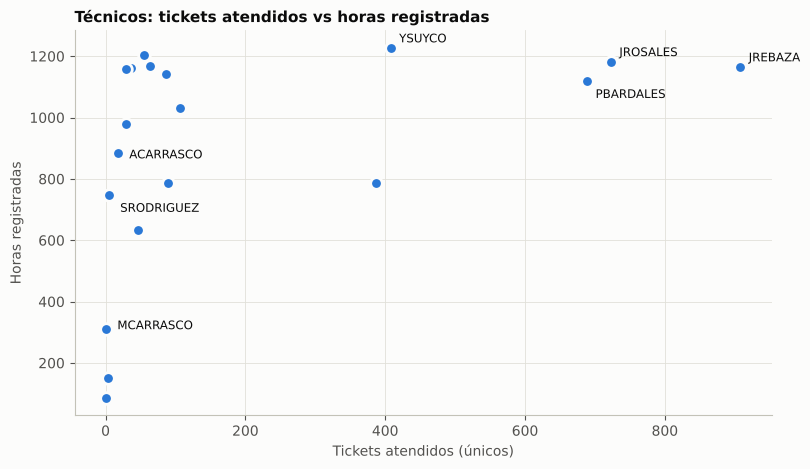

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(tecnicos["Tickets"], tecnicos["Horas"], s=70, color=AZUL, edgecolor="#fcfcfb", linewidth=2, zorder=3)
destacar = {"JREBAZA": (6, 4), "JROSALES": (6, 4), "PBARDALES": (6, -12), "YSUYCO": (6, 4),
            "SRODRIGUEZ": (8, -12), "MCARRASCO": (8, 0), "ACARRASCO": (8, -4)}
for u, desplazamiento in destacar.items():
    ax.annotate(u, (tecnicos.loc[u, "Tickets"], tecnicos.loc[u, "Horas"]), xytext=desplazamiento,
                textcoords="offset points", fontsize=8.5, color=TINTA)
ax.set_title("Técnicos: tickets atendidos vs horas registradas")
ax.set_xlabel("Tickets atendidos (únicos)")
ax.set_ylabel("Horas registradas")
plt.show()

**Interpretación del multivariante**
- **Por tipo:** los **proyectos (PRY)** son solo el 0.5% de los tickets pero consumen el **22% de las horas** (≈ 222 h por ticket). Los **REQ** concentran el 58% de las horas.
  En el otro extremo, los **incidentes (INC)** son el 42% de los tickets pero solo el 11% de las horas (~1.3 h por ticket): mucho volumen y poco esfuerzo unitario.
- **Por grupo:** `SIC` es el gran receptor de demanda (48% de los registros y 38% de las horas) con sesiones cortas (~1.9 h).
  Los grupos con mayor esfuerzo por registro son `HCE UNIFICADA` (7.2 h), `GITHUB` (5.6 h), `HIS` (3.7 h), `PORTAL PROVEEDORES` (3.6 h) y `MAC` (3.5 h), empujados por tickets de larga duración (ver la tabla por grupo).
- **Interacción Grupo × Tipo:** el mismo tipo cuesta distinto según el sistema; p. ej. un PRY de `HCE UNIFICADA` o `MAC` supera las 1,000 h, mientras un PRY de `SIC` promedia ~38 h.
- **Prueba de Kruskal-Wallis:** las diferencias entre tipos y entre grupos son significativas (p < 0.001).
- **Técnicos:** se distinguen dos perfiles: *operativos* (JREBAZA, JROSALES, PBARDALES: 68% de los tickets, ~1.5 h/ticket) y *de proyecto* (SRODRIGUEZ, MCARRASCO, ACARRASCO: pocos tickets con decenas o cientos de horas cada uno).
  Registran entre 8.4 y 10 h por día activo (mediana 9.5 h): las horas registradas cubren la jornada, así que la eficiencia se juega en *cómo* se reparte el trabajo.

## 4. Conclusiones del EDA
1. **Calidad:** tras la limpieza el dataset queda sin nulos, con categorías únicas y trazable (flags por cada corrección). Se retiraron 83 duplicados y se acotaron 55 registros > 10 h.
2. **Horas:** distribución asimétrica a la derecha (mediana 1.5 h, media 2.4 h); usar mediana y percentiles para metas de esfuerzo.
3. **Esfuerzo concentrado:** pocos tickets (PRY y REQ antiguos) explican gran parte de las horas, mientras el volumen lo ponen INC/EXP de corta duración.
4. **Gestión:** las horas registradas ya cubren la jornada (~9.5 h por técnico y día), así que mejorar requiere priorizar y redistribuir, no sumar horas. Estos hallazgos se desarrollan en el informe ejecutivo (Módulo 5).